In [1]:
import pandas as pd
import numpy as np
import pandasql as ps

In [7]:
aave = pd.read_parquet('../data/aave-v3.parquet', engine='auto')

In [ ]:
aave

,reserve_id,timestamp,liquidity_rate,stable_borrow_rate,variable_borrow_rate,liquidity_index,variable_borrow_index,liquidity_apr,stable_borrow_apr,variable_borrow_apr
0,1,2022-03-12 19:19:07,0,60000000000000000000000000,0,1000000000000000000000000000,1000000000000000000000000000,0.000000,6.000000,0.000000
1,1,2022-03-12 19:45:07,0,60000000000000000000000000,0,1000000000000000000000000000,1000000000000000000000000000,0.000000,6.000000,0.000000
2,8,2022-03-12 19:59:07,0,90000000000000000000000000,0,1000000000000000000000000000,1000000000000000000000000000,0.000000,9.000000,0.000000
3,8,2022-03-13 14:32:33,0,90000000000000000000000000,0,1000000000000000000000000000,1000000000000000000000000000,0.000000,9.000000,0.000000
4,1,2022-03-13 18:47:33,0,60000000000000000000000000,0,1000000000000000000000000000,1000000000000000000000000000,0.000000,6.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
8887079,168,2024-06-09 11:11:11,11569151117135226551815377,131657804401699857023302661,41657804401699857023302661,1000070994525036879180964394,1000247246843498183917535326,1.156915,13.165780,4.165780
8887080,168,2024-06-09 11:11:11,11569136334643561197858800,131657777787545679159147440,41657777787545679159147440,1000070994525036879180964394,1000247246843498183917535326,1.156914,13.165778,4.165778
8887081,20,2024-06-09 11:11:47,16660042565596602369405143,93276729212718384147577189,24693710448902868903304032,1025351684693229672227559922,1044025002447348277603304785,1.666004,9.327673,2.469371
8887082,20,2024-06-09 11:12:23,16660029429686159175377369,93276715305429576660993206,24693700713800703662695244,1025351704193689388774811692,1044025031877544014049271806,1.666003,9.327672,2.469370


In [ ]:
aave = aave[aave['reserve_id'].isin([20])]
aave = aave[['reserve_id', 'timestamp', 'liquidity_apr']]

In [ ]:
aave.to_csv('../int/aave_csv.csv', index=False)

configuration 379853410077073136111871992929984913585795781894002,
liquidityIndex 1024255088082056795121396940,
currentLiquidityRate 15670346423052916943710915,
variableBorrowIndex 1042328212395733439393658389,
currentVariableBorrowRate 23949011737370460254646102,
currentStableBorrowRate 92212873910529228935208718,
lastUpdateTimestamp 1715782559,
id 0,
aTokenAddress 0x4d5F47FA6A74757f35C14fD3a6Ef8E3C9BC514E8,
stableDebtTokenAddress 0x102633152313C81cD80419b6EcF66d14Ad68949A,
variableDebtTokenAddress 0xeA51d7853EEFb32b6ee06b1C12E6dcCA88Be0fFE,
interestRateStrategyAddress 0x06B1Ec378618EA736a65395eA5CAB69A2410493B,
accruedToTreasury 33016123704501072007,
unbacked 0,
isolationModeTotalDebt 0

In [ ]:
aave['timestamp'] = pd.to_datetime(aave['timestamp'])

In [ ]:
aave

,reserve_id,timestamp,liquidity_apr
2664841,20,2023-01-27 08:00:11,0.000000
2664842,20,2023-01-27 08:20:47,0.000000
2664843,20,2023-01-27 08:22:23,0.000000
2664845,20,2023-01-27 08:24:35,0.000000
2664847,20,2023-01-27 08:33:59,0.000000
...,...,...,...
8886724,20,2024-06-09 10:54:47,1.665997
8886839,20,2024-06-09 11:01:47,1.665998
8886841,20,2024-06-09 11:02:35,1.665994
8887081,20,2024-06-09 11:11:47,1.666004


In [ ]:
# Define the SQL query
query = """
SELECT
    reserve_id,
    strftime('%Y-%m-%d', timestamp) as timestamp,
    avg(liquidity_apr) as liquidity_apr
FROM aave
GROUP BY reserve_id, strftime('%Y-%m-%d', timestamp)
"""

# Execute the query
aave_grouped = ps.sqldf(query, locals())

# Display the resulting DataFrame
print(aave_grouped)

     reserve_id   timestamp  liquidity_apr
0            20  2023-01-27       2.057675
1            20  2023-01-28       3.179303
2            20  2023-01-29       1.414550
3            20  2023-01-30       1.783108
4            20  2023-01-31       1.461757
..          ...         ...            ...
495          20  2024-06-05       1.724224
496          20  2024-06-06       1.695927
497          20  2024-06-07       1.689780
498          20  2024-06-08       1.679762
499          20  2024-06-09       1.668068

[500 rows x 3 columns]


In [ ]:
aave_grouped

,reserve_id,timestamp,liquidity_apr
slot,,,
5666400.0,20,2023-01-27,2.057675
5673600.0,20,2023-01-28,3.179303
5680800.0,20,2023-01-29,1.414550
5688000.0,20,2023-01-30,1.783108
5695200.0,20,2023-01-31,1.461757
...,...,...,...
9230400.0,20,2024-06-05,1.724224
9237600.0,20,2024-06-06,1.695927
9244800.0,20,2024-06-07,1.689780


In [ ]:
import pandas as pd

# Assuming aave_grouped DataFrame is already defined and 'slot' and 'timestamp' columns exist

# Set initial slot values
aave_grouped.loc[aave_grouped['timestamp'] == '2023-01-27', 'slot'] = 5666400

# Sort the DataFrame by timestamp to ensure the order is correct
aave_grouped = aave_grouped.sort_values(by='timestamp').reset_index(drop=True)

# Get the index of the known slot value
initial_index = aave_grouped.loc[aave_grouped['timestamp'] == '2023-01-27'].index[0]

# Fill subsequent rows
for i in range(initial_index + 1, len(aave_grouped)):
    aave_grouped.loc[i, 'slot'] = aave_grouped.loc[i - 1, 'slot'] + 7200

# Backfill previous rows
for i in range(initial_index - 1, -1, -1):
    aave_grouped.loc[i, 'slot'] = aave_grouped.loc[i + 1, 'slot'] - 7200

# Set 'slot' as index
aave_grouped.set_index('slot', inplace=True)

aave_grouped


,reserve_id,timestamp,liquidity_apr
slot,,,
5666400.0,20,2023-01-27,2.057675
5673600.0,20,2023-01-28,3.179303
5680800.0,20,2023-01-29,1.414550
5688000.0,20,2023-01-30,1.783108
5695200.0,20,2023-01-31,1.461757
...,...,...,...
9230400.0,20,2024-06-05,1.724224
9237600.0,20,2024-06-06,1.695927
9244800.0,20,2024-06-07,1.689780


In [ ]:
aave_grouped.to_csv('../int/aave_grouped.csv')

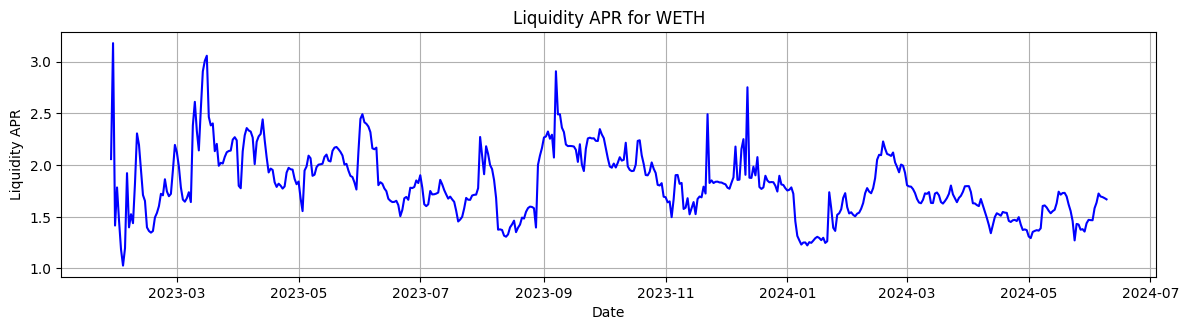

In [ ]:
import matplotlib.pyplot as plt

# Convert 'timestamp' to datetime
aave_grouped['timestamp'] = pd.to_datetime(aave_grouped['timestamp'])

# Filter the DataFrame for reserve_id 20 and 21
aave_20 = aave_grouped[aave_grouped['reserve_id'] == 20]

# Plotting reserve_id 20
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(aave_20['timestamp'], aave_20['liquidity_apr'], linestyle='-', color='b')
plt.title('Liquidity APR for WETH')
plt.xlabel('Date')
plt.ylabel('Liquidity APR')
plt.grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [ ]:
eth_price = pd.read_csv('../data/eth-usd.csv', usecols=['snapped_at','price'])
eth_price.loc[eth_price['snapped_at'] == '2024-05-13 00:00:00 UTC', 'slot'] = 9060299
for i in range(3201, -1, -1):
    eth_price.at[i, 'slot'] = 9060299 - (3201 - i) * 7200
eth_price = eth_price[eth_price['slot']>=0]
eth_price = eth_price.drop(columns=['snapped_at'])
eth_price


,price,slot
1943,589.581844,2699.0
1944,598.760610,9899.0
1945,616.506662,17099.0
1946,571.190432,24299.0
1947,595.919414,31499.0
...,...,...
3197,2975.726966,9031499.0
3198,3038.344705,9038699.0
3199,2910.684500,9045899.0
3200,2908.982785,9053099.0


In [ ]:
slots_df = pd.DataFrame({'slot': range(31499, 8986176)})
eth_price['price_pct_change'] = eth_price['price'].pct_change()
eth_price.dropna(subset=['price', 'price_pct_change'], inplace=True)
eth_price = eth_price[(eth_price[['price_pct_change']] != 0).all(axis=1)]
eth_price = pd.merge(slots_df, eth_price[['slot', 'price', 'price_pct_change']], on='slot', how='left')
eth_price = eth_price.ffill()
eth_price.set_index('slot', inplace=True)
eth_price

,price,price_pct_change
slot,,
31499,595.919414,0.043294
31500,595.919414,0.043294
31501,595.919414,0.043294
31502,595.919414,0.043294
31503,595.919414,0.043294
...,...,...
8986171,2976.090208,-0.014066
8986172,2976.090208,-0.014066
8986173,2976.090208,-0.014066


In [ ]:
eth_price.to_csv('../int/eth_price.csv')

In [ ]:
# Load the data
curve = pd.read_csv('../data/curve_eth_steth_apr.csv')

# Keep only relevant columns
curve = curve[['time', 'Total APR,%']]

# Convert 'time' column to datetime
curve['time'] = pd.to_datetime(curve['time'])

# Define the reference slot and date
reference_date = pd.to_datetime('2024-05-13 00:00:00')
reference_slot = 9064800

# Calculate the difference in days from the reference date
curve['days_diff'] = (curve['time'] - reference_date).dt.days

# Calculate the slot value for each row
curve['slot'] = reference_slot + (curve['days_diff'] * 7200)

# Drop the 'days_diff' column as it's no longer needed
curve.drop(columns=['days_diff'], inplace=True)
curve.rename(columns={'Total APR,%': 'liquidity_apr'}, inplace=True)
# Print the updated DataFrame
print(curve)

          time  liquidity_apr     slot
0   2022-01-01       6.329546  2851200
1   2022-01-02       6.202780  2858400
2   2022-01-03       5.831714  2865600
3   2022-01-04       5.766225  2872800
4   2022-01-05       5.896542  2880000
..         ...            ...      ...
879 2024-05-29       1.699147  9180000
880 2024-05-30       1.765454  9187200
881 2024-05-31       1.884119  9194400
882 2024-06-01       1.689537  9201600
883 2024-06-02       1.749338  9208800

[884 rows x 3 columns]


In [ ]:
curve.to_csv('../int/curve_grouped.csv')